# EDA

In [3]:
from statsmodels.graphics.tsaplots import plot_acf  
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')

from utils.grafico_estacional import grafico_estacional

In [2]:
df = pd.read_csv('../datos/df_01.csv',
                parse_dates = ['fecha'],
                index_col = 'fecha')
df

,value
fecha,
2019-01-01 00:00:00,23216.0
2019-01-01 01:00:00,24947.0
2019-01-01 02:00:00,27655.0
2019-01-01 03:00:00,27676.0
2019-01-01 04:00:00,26853.0
...,...
2025-07-19 20:00:00,29380.0
2025-07-19 21:00:00,27763.0
2025-07-19 22:00:00,26659.0


### Descomposición de la serie por tendencia, estacionalidad y ruido

In [5]:
dec_add  = seasonal_decompose(df, model = 'additive')
dec_mul = seasonal_decompose(df, model = 'multiplicative')

Text(0.5, 0.98, 'Comparación: Descomposición Aditiva vs. Multiplicativa')

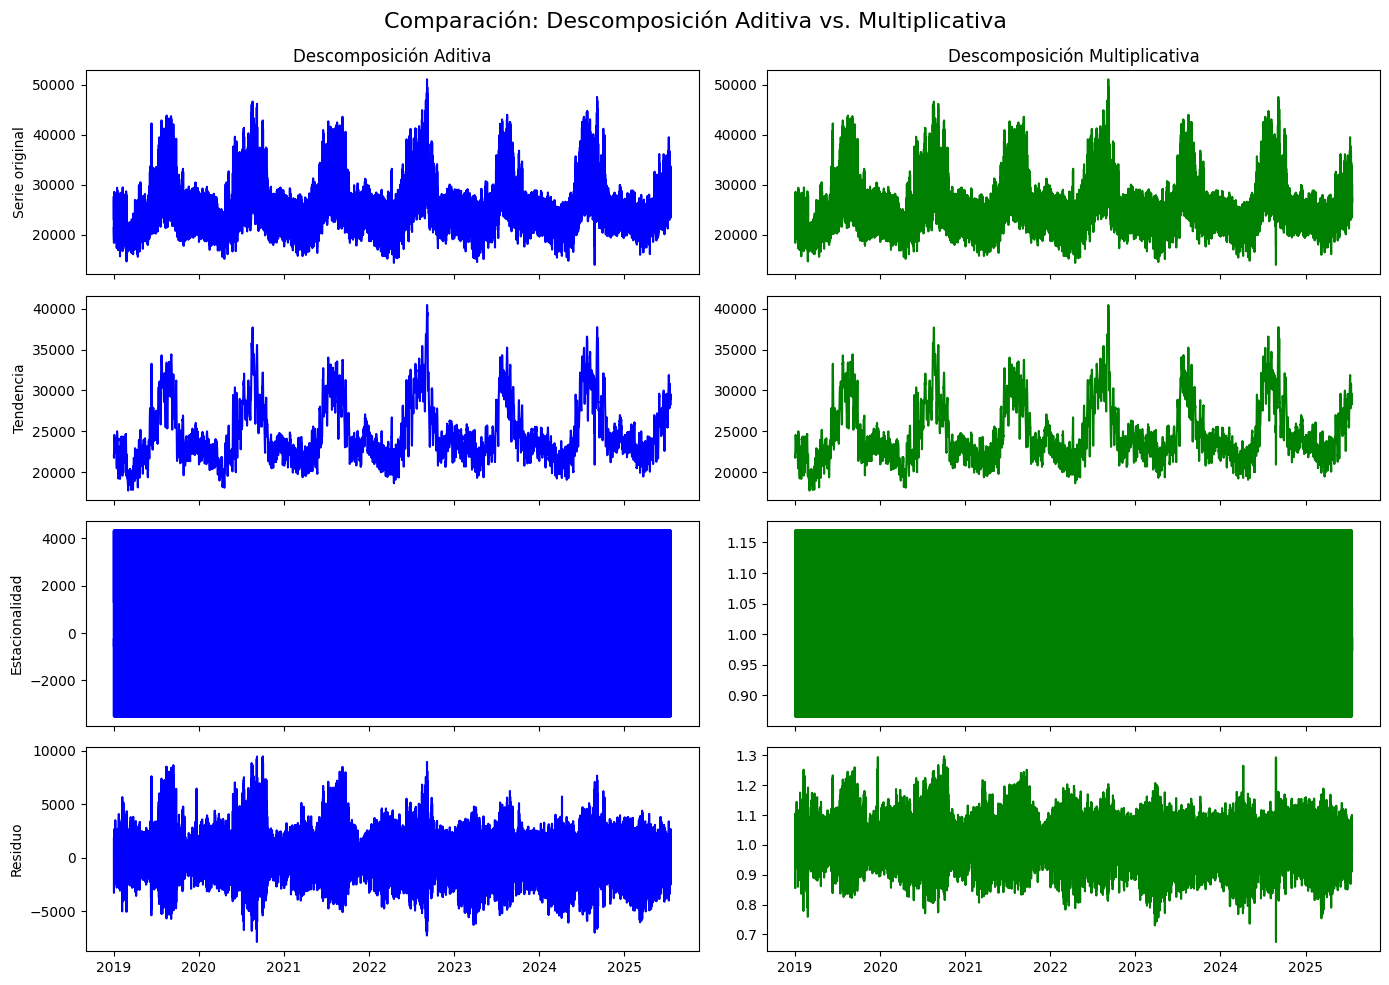

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

# Títulos por columna
axes[0, 0].set_title("Descomposición Aditiva")
axes[0, 1].set_title("Descomposición Multiplicativa")

# Etiquetas de las filas
componentes = ['Serie original', 'Tendencia', 'Estacionalidad', 'Residuo']
datos_add = [dec_add.observed, dec_add.trend, dec_add.seasonal, dec_add.resid]
datos_mul = [dec_mul.observed, dec_mul.trend, dec_mul.seasonal, dec_mul.resid]

for i in range(4):
    axes[i, 0].plot(datos_add[i], color='blue')
    axes[i, 1].plot(datos_mul[i], color='green')
    axes[i, 0].set_ylabel(componentes[i])

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.92)
fig.suptitle("Comparación: Descomposición Aditiva vs. Multiplicativa", fontsize=16)

hay que observar el comportamiento de el último año para poder observar mejor el fenómeno de estacionalidad

Text(0.5, 0.98, 'Comparación: Descomposición Aditiva vs. Multiplicativa')

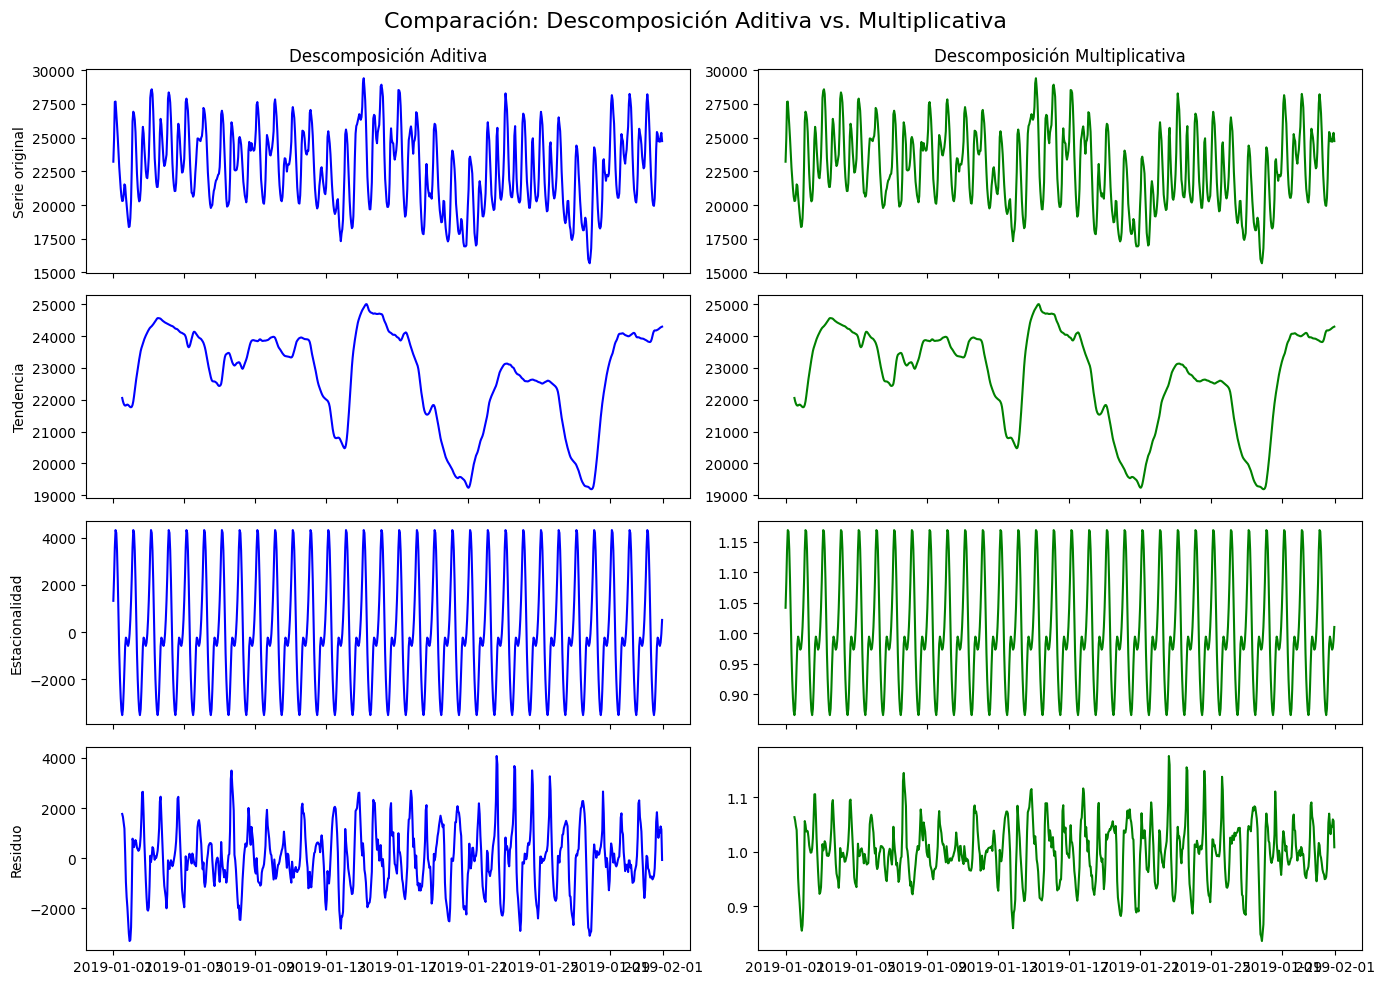

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

# Títulos por columna
axes[0, 0].set_title("Descomposición Aditiva")
axes[0, 1].set_title("Descomposición Multiplicativa")

# Etiquetas de las filas
periodo = '2019-1'
componentes = ['Serie original', 'Tendencia', 'Estacionalidad', 'Residuo']
datos_add = [dec_add.observed[periodo], dec_add.trend[periodo], dec_add.seasonal[periodo], dec_add.resid[periodo]]
datos_mul = [dec_mul.observed[periodo], dec_mul.trend[periodo], dec_mul.seasonal[periodo], dec_mul.resid[periodo]]

for i in range(4):
    axes[i, 0].plot(datos_add[i], color='blue')
    axes[i, 1].plot(datos_mul[i], color='green')
    axes[i, 0].set_ylabel(componentes[i])

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.92)
fig.suptitle("Comparación: Descomposición Aditiva vs. Multiplicativa", fontsize=16)

Pareciera que no hay una tendencia clara, pero que si hay presente un patrón estacional tanto en las descomposiciónes aditiva y multiplicativa

### Posible estacionalidad

Hay que en contrar la periodicidad en la que está presente esa estacionalidad

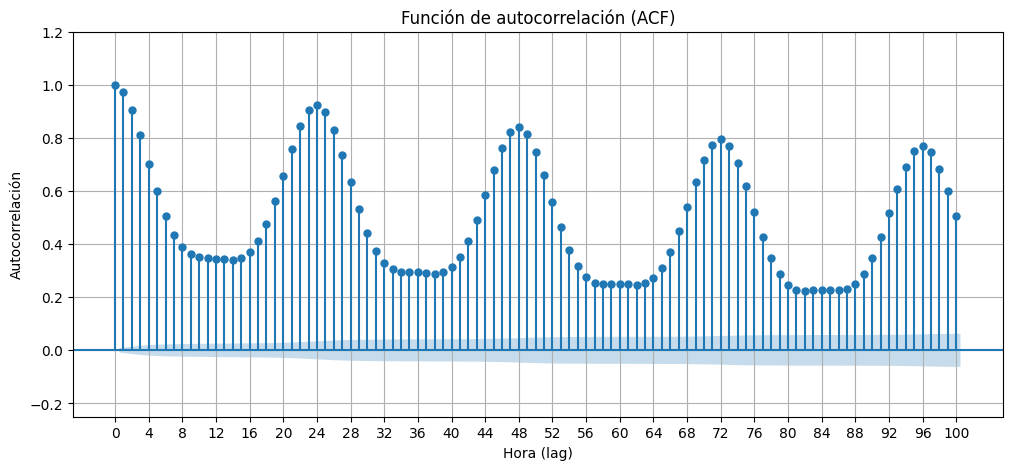

In [11]:
fig, ax = plt.subplots(1, figsize=(12,5))
fig = plot_acf(df, lags=100, ax=ax)

# Personalizar figura
xticks = np.arange(0,101,4)
ax.grid()
ax.set_ylim([-0.25, 1.2])
ax.set_xticks(xticks)
ax.set_xlabel('Hora (lag)')
ax.set_ylabel('Autocorrelación')
ax.set_title('Función de autocorrelación (ACF)');

* Los registros se toman cada hora, y se puede notar que la estacionalidad de la serie tiene presente una periodicidad en múltiplos enteros de 24 horas.
* El patrón estacional se va debilitando suavemente con el tiempo, por lo que puede existir un componente AR

Text(0.5, 1.0, 'Función de autocorrelación parcial (PACF)')

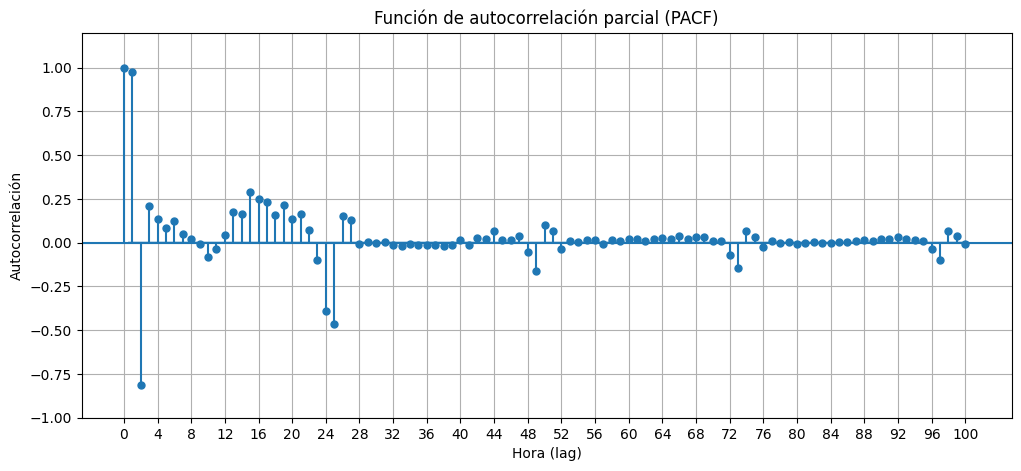

In [13]:
# Análisis de posible estacionalidad usando la función de autocorrelación parcial
from statsmodels.graphics.tsaplots import plot_pacf
import numpy as np

fig, ax = plt.subplots(1, figsize=(12,5))
fig = plot_pacf(df, lags=100, ax=ax)

# Personalizar figura
xticks = np.arange(0,101,4) # Etiqueta eje horizontal cada 4 horas
ax.grid()
ax.set_ylim([-1, 1.2])
ax.set_xticks(xticks)
ax.set_xlabel('Hora (lag)')
ax.set_ylabel('Autocorrelación')
ax.set_title('Función de autocorrelación parcial (PACF)')

### Gráficos estacionales

In [14]:
ts = df['value'].copy().to_frame()
ts['hora'] = ts.index.hour
ts['mes'] = ts.index.month
ts['año'] = ts.index.year
ts

,value,hora,mes,año
fecha,,,,
2019-01-01 00:00:00,23216.0,0,1,2019
2019-01-01 01:00:00,24947.0,1,1,2019
2019-01-01 02:00:00,27655.0,2,1,2019
2019-01-01 03:00:00,27676.0,3,1,2019
2019-01-01 04:00:00,26853.0,4,1,2019
...,...,...,...,...
2025-07-19 20:00:00,29380.0,20,7,2025
2025-07-19 21:00:00,27763.0,21,7,2025
2025-07-19 22:00:00,26659.0,22,7,2025


In [15]:
gb = ts.groupby(['mes', 'hora'])['value'].mean()
gb

mes  hora
1    0       23005.949309
     1       23881.216590
     2       25709.677419
     3       26854.216590
     4       26708.917051
                 ...     
12   19      24503.021505
     20      24113.188172
     21      23861.155914
     22      23837.854839
     23      24054.059140
Name: value, Length: 288, dtype: float64

#### Gráfico estacional para meses

Sucio por la tendenia


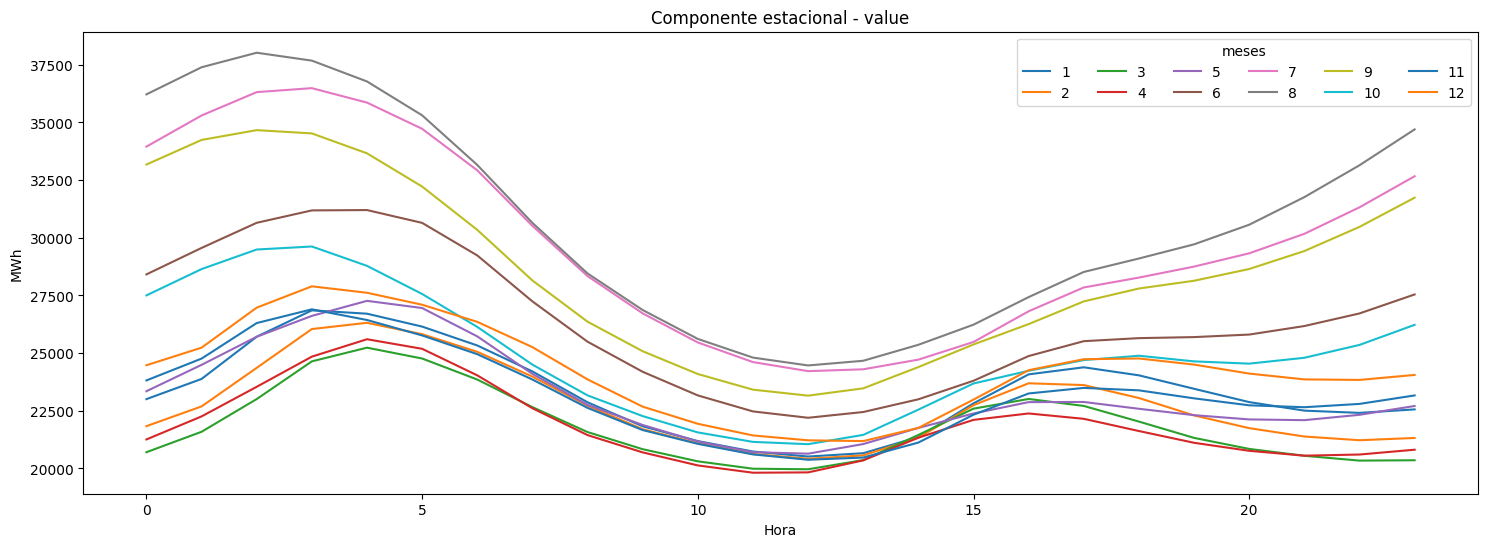

Limpio sin tendencia, solo componente estacional


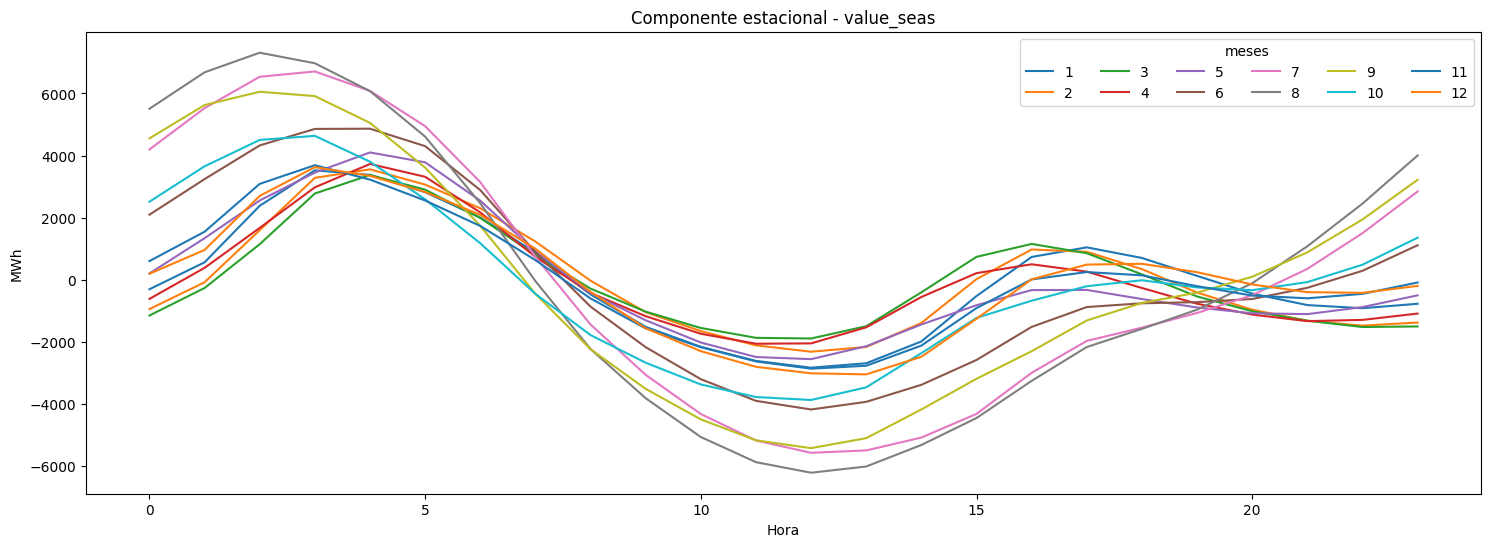

In [16]:
print('Sucio por la tendenia')
grafico_estacional(ts, 'value', 24, 'meses', False)

print('Limpio sin tendencia, solo componente estacional')
grafico_estacional(ts, 'value', 24, 'meses', True)

    > Independientemente del Mes del año, en las mañanas se tiene una mayor demanda de energía
    > Todos los días siguen un comportamiento muy similar

#### Gráfico estacional para años

Sucio por la tendenia


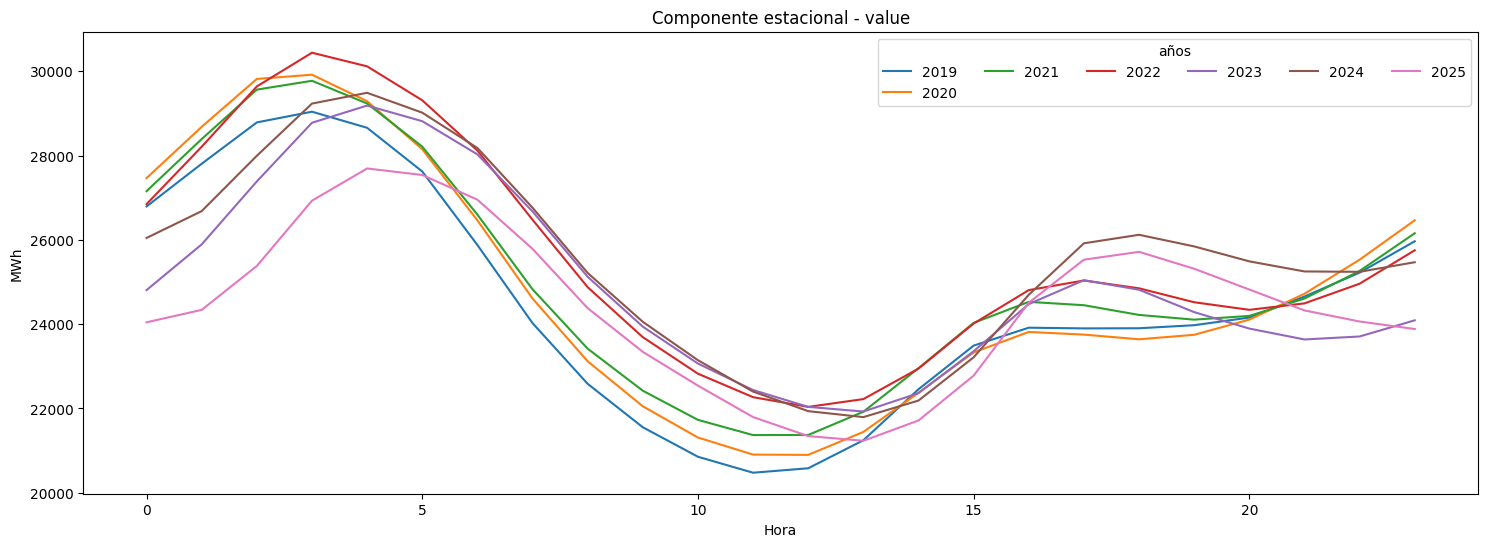

Limpio sin tendencia, solo componente estacional


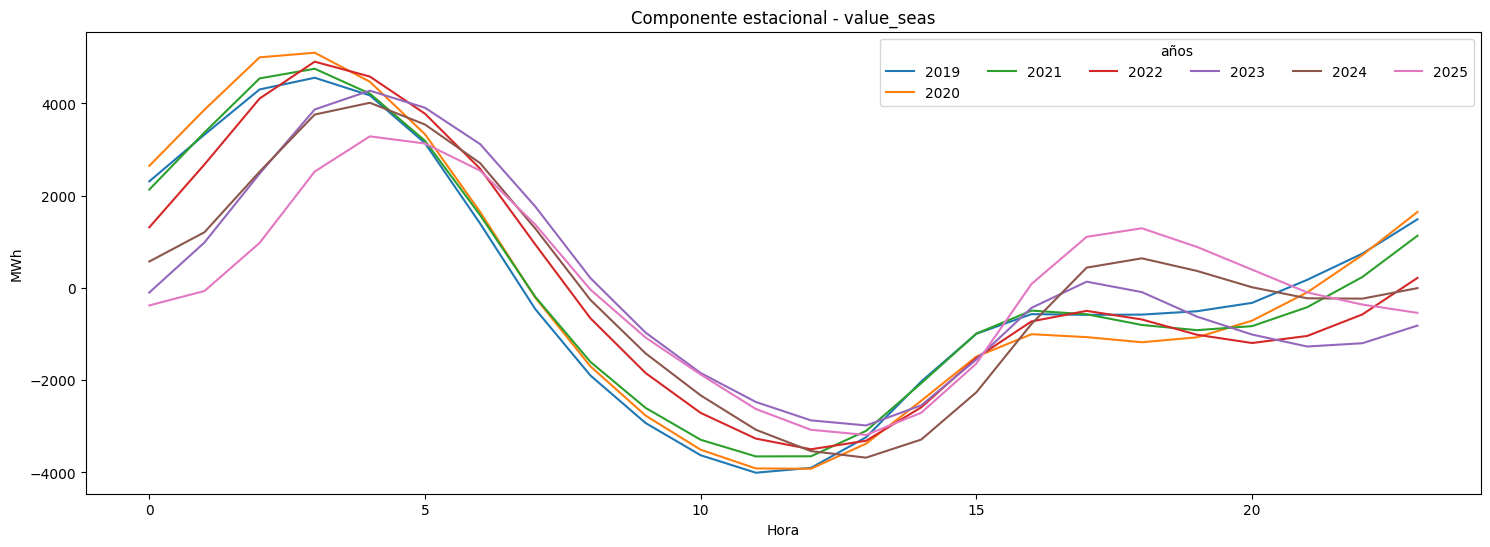

In [17]:
print('Sucio por la tendenia')
grafico_estacional(ts, 'value', 24, 'años', False)

print('Limpio sin tendencia, solo componente estacional')
grafico_estacional(ts, 'value', 24, 'años', True)

    > La gráfca anterior nos permite reconfirmar el comportamiento periódico de la serie, con una demanda que crece hacia las horas de la madrugada y que decrece hacia la media noche.

## Resumen

- La serie original parace no tener una tendencia marcada asendente o descendente
- Se tiene una frecuencia de registro de los datos cada hora
- Se tienen registros desde 2019 hasta 2025
- Existe una estacionalidad en **periodos de 24 horas**
- La función de autocorrelación nos indica presencia de un componente Auto Regresivo

> SARIMA puede ser una buena opción